
# Finals of Univariate-Imputation
### 1. Random Imputation
> here, we'll randomly select the values from values already available in the column
### 2. Missing value Indicator
> Indicating whether values are missing
### 3. GridSearchCV -> finding best parameters for imputation
> A techinque used for HyperParameter Tuning
---

In [38]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [22]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


--- 

# Random imputation

In [23]:
df.isnull().mean() * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [26]:
df['age_2'] = df['age']
# df[['age','age_2']]

missing_values = df['age'].isnull().sum()

total_values = df['age'].dropna().sample(missing_values).values

# df['age_2'][df['age_2'].isnull()] = total_values
df.loc[df['age_2'].isnull(), 'age_2'] = total_values

In [27]:
# df.age_2.isnull().sum()
df.isnull().mean() * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
age_2           0.000000
dtype: float64

In [31]:
df.sample(10)[['age', 'age_2']]

,age,age_2
513,54.0,54.0
670,40.0,40.0
451,NaN,57.0
855,18.0,18.0
77,NaN,51.0
497,NaN,22.0
795,39.0,39.0
174,56.0,56.0
15,55.0,55.0
357,38.0,38.0


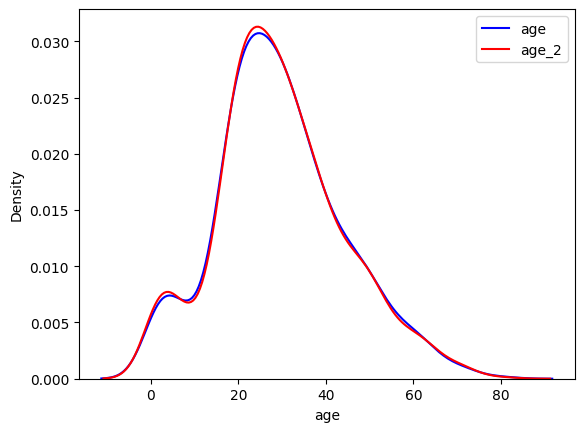

In [39]:
sns.kdeplot(df['age'], label='age',color='blue')
sns.kdeplot(df['age_2'], label='age_2',color='red')

plt.legend()

---

# Missing value Indicator
> if you are using SimpleImputer?
 
<br> 
just set 'add_indiactor' = true

In [45]:
from sklearn.impute import SimpleImputer
si = SimpleImputer(add_indicator=True)

In [47]:
df[['age_3', 'age_3_missing']] = si.fit_transform(df[['age']])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_2,age_3,age_3_missing
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0,22.0,0.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0,38.0,0.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0,26.0,0.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0,35.0,0.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0,35.0,0.0


In [ ]:
df.age_3_missing.value_counts()

age_3_missing
0.0    714
1.0    177
Name: count, dtype: int64

In [54]:
df.age.isnull().sum()

np.int64(177)

---
> If it's not a pre-built imputer, use 

## MissingIndicator in Sklearn
> this sometimes imporves the accuracy of model, in some used-cases it improved the model accuracy by 10%

In [55]:
from sklearn.impute import MissingIndicator
mi = MissingIndicator()

In [57]:
df['age_missing'] = mi.fit_transform(df[['age']])
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_2,age_3,age_3_missing,age_missing
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.0,22.0,0.0,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.0,38.0,0.0,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.0,26.0,0.0,False
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.0,35.0,0.0,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.0,35.0,0.0,False
